# Day 11 — Cost / latency / accuracy tradeoffs

Benchmarks (Day 10) tell you a model *can* do the task. This hour is the *should you pay for
it* question. We build a tradeoff calculator: a model lineup, a Pareto frontier, a
total-cost-at-volume model, a latency budget, and a **cascade router** that beats every single
model on cost-for-accuracy.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | The three axes and why you can't max all three | 3 min |
| 1 | A model lineup + the cost-per-call formula | 10 min |
| 2 | The Pareto frontier: which models are never the right choice | 12 min |
| 3 | Latency: p50 vs p95, streaming, and the budget | 10 min |
| 4 | Total cost at volume + caching | 10 min |
| 5 | The cascade router: cheap-first, escalate on doubt | 12 min |
| 6 | Exercises + quiz | 3 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)
print("ready")

ready


## 0 — The three axes (3 min)

- **Accuracy** — task quality (your eval, not a benchmark).
- **Cost** — $ per call: `(in_tokens · price_in + out_tokens · price_out)`.
- **Latency** — time to first token + time per output token; users feel p95, not p50.

Bigger models buy accuracy with cost and latency. The skill is finding the **smallest model
that clears your quality bar**, then spending the savings on volume, retries, or a cascade.

## 1 — A model lineup (10 min)

Illustrative numbers in the shape of a real 2024–25 lineup (prices $/million tokens). `acc` is
this model's score on *our* task eval.

In [2]:
MODELS = {
 # name          price_in  price_out  ttft_s  s_per_tok   acc
 "nano":    dict(pin=0.05,  pout=0.20,  ttft=0.20, spt=0.0020, acc=0.71),
 "small":   dict(pin=0.15,  pout=0.60,  ttft=0.25, spt=0.0025, acc=0.83),
 "mid":     dict(pin=0.50,  pout=1.50,  ttft=0.35, spt=0.0035, acc=0.90),
 "large":   dict(pin=3.00,  pout=15.00, ttft=0.55, spt=0.0060, acc=0.945),
 "frontier":dict(pin=10.0,  pout=40.00, ttft=0.90, spt=0.0110, acc=0.962),
 # an older release still on the price list: pricier than 'mid', less accurate, slower
 "legacy":  dict(pin=1.00,  pout=3.00,  ttft=0.70, spt=0.0070, acc=0.86),
}
IN_TOK, OUT_TOK = 800, 250          # typical call for our task

def cost_per_call(m):
    d = MODELS[m]
    return (IN_TOK*d["pin"] + OUT_TOK*d["pout"]) / 1e6

def latency(m, out_tok=OUT_TOK):
    d = MODELS[m]
    return d["ttft"] + out_tok*d["spt"]

print(f"{'model':10s} {'acc':>6} {'$/call':>10} {'$/1k calls':>12} {'latency s':>10}")
for m in MODELS:
    print(f"{m:10s} {MODELS[m]['acc']:>6.3f} {cost_per_call(m):>10.5f} "
          f"{cost_per_call(m)*1000:>12.3f} {latency(m):>10.2f}")

model         acc     $/call   $/1k calls  latency s
nano        0.710    0.00009        0.090       0.70
small       0.830    0.00027        0.270       0.88
mid         0.900    0.00077        0.775       1.23
large       0.945    0.00615        6.150       2.05
frontier    0.962    0.01800       18.000       3.65
legacy      0.860    0.00155        1.550       2.45


Note the shape: going `mid → frontier` is **+6 accuracy points for ~13× the cost and ~2× the
latency**. Whether that trade is worth it depends entirely on what those 6 points are worth in
your product.

## 2 — The Pareto frontier (12 min)

A model is **dominated** if another model is at least as good on *every* axis and strictly
better on one. Dominated models are never the rational choice — drop them from consideration.

In [3]:
def pareto(models, axes):
    # axes: dict name -> +1 (higher better) or -1 (lower better)
    names = list(models)
    keep = []
    for a in names:
        dominated = False
        for b in names:
            if a == b: continue
            better_or_equal = all(
                (axes[k]*(models[b][k] - models[a][k]) >= 0) for k in axes)
            strictly_better = any(
                (axes[k]*(models[b][k] - models[a][k]) > 0) for k in axes)
            if better_or_equal and strictly_better:
                dominated = True; break
        if not dominated: keep.append(a)
    return keep

feat = {m: dict(acc=MODELS[m]["acc"], cost=cost_per_call(m), lat=latency(m)) for m in MODELS}
frontier = pareto(feat, dict(acc=+1, cost=-1, lat=-1))
print("on the frontier:", frontier)
print("dominated      :", [m for m in MODELS if m not in frontier])

on the frontier: ['nano', 'small', 'mid', 'large', 'frontier']
dominated      : ['legacy']


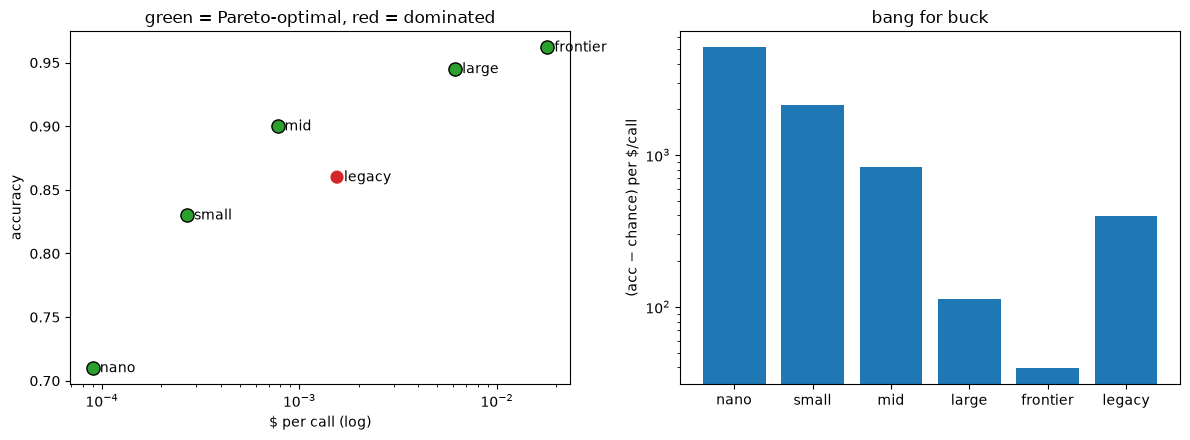

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
accs = [feat[m]["acc"] for m in MODELS]; costs = [feat[m]["cost"] for m in MODELS]
lats = [feat[m]["lat"] for m in MODELS]
for i, m in enumerate(MODELS):
    on = m in frontier
    ax[0].scatter(costs[i], accs[i], s=90, edgecolor="k" if on else "none",
                  c="tab:green" if on else "tab:red")
    ax[0].annotate(m, (costs[i], accs[i]), xytext=(5,-3), textcoords="offset points")
ax[0].set_xscale("log"); ax[0].set_xlabel("$ per call (log)"); ax[0].set_ylabel("accuracy")
ax[0].set_title("green = Pareto-optimal, red = dominated")
# accuracy per dollar
apc = [(feat[m]["acc"]-0.25)/feat[m]["cost"] for m in MODELS]
ax[1].bar(list(MODELS), apc)
ax[1].set_ylabel("(acc − chance) per $/call"); ax[1].set_title("bang for buck"); ax[1].set_yscale("log")
plt.tight_layout(); plt.show()

Reading the frontier: pick the **leftmost model that clears your accuracy bar**. If your bar is
0.88, `mid` is the answer and everything pricier is waste. If your bar is 0.95, only
`frontier` qualifies and you pay for it. If nothing clears the bar → that's the Week 3
fine-tuning signal, or the Week 6 RAG signal.

## 3 — Latency: p50 vs p95 (10 min)

Users experience the *tail*. Real latency has variance (queueing, variable output length,
load). Model it and look at p95.

In [5]:
def sample_latency(m, n=20000):
    d = MODELS[m]
    ttft = rng.gamma(shape=4, scale=d["ttft"]/4, size=n)          # right-skewed
    out_len = rng.poisson(OUT_TOK, size=n)
    jitter = rng.lognormal(mean=0, sigma=0.25, size=n)            # load multiplier
    return (ttft + out_len*d["spt"]) * jitter

print(f"{'model':10s} {'p50':>7} {'p95':>7} {'p99':>7}")
for m in MODELS:
    s = sample_latency(m)
    print(f"{m:10s} {np.percentile(s,50):>7.2f} {np.percentile(s,95):>7.2f} {np.percentile(s,99):>7.2f}")

model          p50     p95     p99
nano          0.69    1.12    1.36
small         0.86    1.39    1.69
mid           1.21    1.95    2.39
large         2.03    3.26    3.97
frontier      3.60    5.75    7.02
legacy        2.42    3.90    4.79


In [6]:
# Streaming changes the *perceived* latency: user sees tokens at TTFT, not at completion.
BUDGET_TTFT = 0.8     # "first token within 0.8s feels responsive"
BUDGET_TOTAL = 4.0    # "full answer within 4s"
for m in MODELS:
    s = sample_latency(m)
    ttft_ok = MODELS[m]["ttft"]*1.5 < BUDGET_TTFT      # rough p95 of ttft
    total_ok = np.percentile(s, 95) < BUDGET_TOTAL
    print(f"{m:10s} streaming-first-token {'OK ' if ttft_ok else 'FAIL'}   "
          f"p95-total {'OK' if total_ok else 'FAIL'}")
print("\n-> if you stream, 'frontier' can still feel responsive (fast first token) even though")
print("   its p95 total blows the non-streaming budget. If you DON'T stream, it fails.")

nano       streaming-first-token OK    p95-total OK
small      streaming-first-token OK    p95-total OK
mid        streaming-first-token OK    p95-total OK
large      streaming-first-token FAIL   p95-total OK
frontier   streaming-first-token FAIL   p95-total FAIL
legacy     streaming-first-token FAIL   p95-total OK

-> if you stream, 'frontier' can still feel responsive (fast first token) even though
   its p95 total blows the non-streaming budget. If you DON'T stream, it fails.


## 4 — Total cost at volume + caching (10 min)

In [7]:
CALLS_PER_MONTH = 2_000_000
def monthly_cost(m, calls=CALLS_PER_MONTH, cache_hit_rate=0.0, cache_discount=0.9):
    base = cost_per_call(m) * calls
    # cached input tokens billed at (1 - discount); assume caching only helps input side
    d = MODELS[m]
    cached_saving = cache_hit_rate * (IN_TOK*d["pin"]/1e6) * calls * cache_discount
    return base - cached_saving

print(f"{'model':10s} {'$/mo no cache':>15} {'$/mo 60% cache':>16}")
for m in MODELS:
    print(f"{m:10s} {monthly_cost(m):>15,.0f} {monthly_cost(m, cache_hit_rate=0.6):>16,.0f}")

print(f"\nfrontier vs mid, no cache: ${monthly_cost('frontier')-monthly_cost('mid'):,.0f}/month "
      f"for +{MODELS['frontier']['acc']-MODELS['mid']['acc']:.3f} accuracy")
print(f"that delta pays ~{(monthly_cost('frontier')-monthly_cost('mid'))/12000:.1f} engineer-months/yr")

model        $/mo no cache   $/mo 60% cache
nano                   180              137
small                  540              410
mid                  1,550            1,118
large               12,300            9,708
frontier            36,000           27,360
legacy               3,100            2,236

frontier vs mid, no cache: $34,450/month for +0.062 accuracy
that delta pays ~2.9 engineer-months/yr


Prompt caching (repeated system prompts / few-shot blocks / RAG preamble) commonly cuts input
cost 50–90% on the cached portion. It's the cheapest optimization: reorder the prompt so the
stable part is first, and the provider caches it.

## 5 — The cascade router (12 min)

**Idea:** run the cheap model first. If it's confident, ship its answer. If not, escalate to a
bigger model. Most calls are easy → most calls cost pennies → blended accuracy approaches the
big model's at a fraction of the cost.

In [8]:
N = 20000

# Each cheap model has a confidence signal. Key numbers:
#   conf_rate  = fraction of calls it flags as "I'm confident"
#   acc_conf   = its accuracy ON those confident calls (higher than its overall acc --
#                that's the whole point of the filter)
# Non-confident calls get escalated and answered by the expensive model.
CASC = {
 "nano":  dict(conf_rate=0.55, acc_conf=0.94),
 "small": dict(conf_rate=0.70, acc_conf=0.965),
 "mid":   dict(conf_rate=0.82, acc_conf=0.980),
}

def run_single(model):
    ok = rng.random(N) < MODELS[model]["acc"]
    return ok.mean(), cost_per_call(model) * N

def run_cascade(cheap, expensive, force_escalate_frac=0.0):
    c = CASC[cheap]
    is_conf = rng.random(N) < c["conf_rate"]
    force = rng.random(N) < force_escalate_frac        # always-escalate a slice for safety
    keep = is_conf & ~force
    ok = np.empty(N, bool)
    ok[keep] = rng.random(keep.sum()) < c["acc_conf"]
    esc = ~keep
    ok[esc]  = rng.random(esc.sum())  < MODELS[expensive]["acc"]
    cost = cost_per_call(cheap)*N + cost_per_call(expensive)*esc.sum()
    return ok.mean(), cost, esc.mean()

for m in ["small", "mid", "large", "frontier"]:
    a, c = run_single(m)
    print(f"single {m:9s}: acc {a:.3f}  cost ${c:8.2f}")

print()
for cheap, exp in [("small","frontier"), ("nano","large"), ("mid","frontier")]:
    a, c, esc = run_cascade(cheap, exp)
    print(f"cascade {cheap:5s} -> {exp:8s}: acc {a:.3f}  cost ${c:8.2f}  escalated {esc:.0%}")

single small    : acc 0.828  cost $    5.40
single mid      : acc 0.900  cost $   15.50
single large    : acc 0.947  cost $  123.00
single frontier : acc 0.964  cost $  360.00

cascade small -> frontier: acc 0.964  cost $  113.27  escalated 30%
cascade nano  -> large   : acc 0.945  cost $   57.70  escalated 45%
cascade mid   -> frontier: acc 0.976  cost $   79.20  escalated 18%


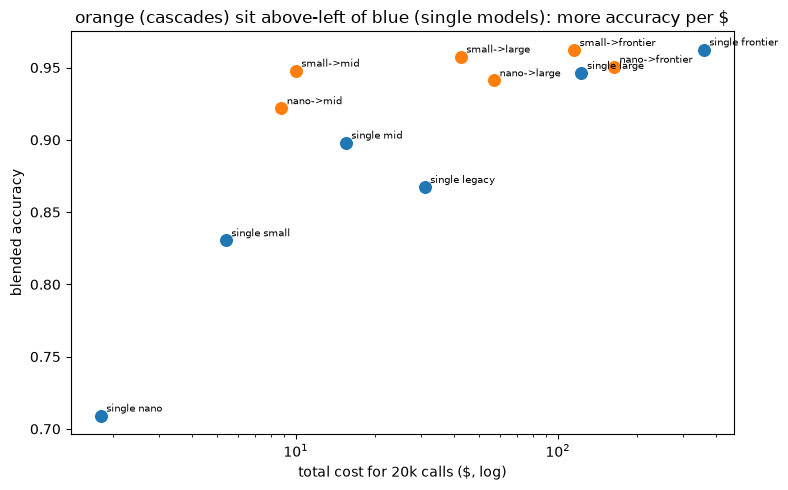

In [9]:
# plot the frontier that cascades unlock
pts = []
for m in MODELS:
    a, c = run_single(m); pts.append((c, a, f"single {m}"))
for cheap in ["nano","small"]:
    for exp in ["mid","large","frontier"]:
        a,c,esc = run_cascade(cheap, exp); pts.append((c, a, f"{cheap}->{exp}"))

plt.figure(figsize=(8,5))
for c,a,lbl in pts:
    single = lbl.startswith("single")
    plt.scatter(c, a, c="tab:blue" if single else "tab:orange", s=70)
    plt.annotate(lbl, (c,a), fontsize=7, xytext=(4,3), textcoords="offset points")
plt.xscale("log"); plt.xlabel("total cost for 20k calls ($, log)"); plt.ylabel("blended accuracy")
plt.title("orange (cascades) sit above-left of blue (single models): more accuracy per $")
plt.tight_layout(); plt.show()

Cascades work when: (a) a cheap confidence signal exists (logprobs, self-check, a small
verifier), (b) the task has a fat easy head, (c) escalation latency is acceptable (you may pay
2 calls). Downsides: added complexity, double latency on escalated calls, confidence-signal
calibration drift. Related patterns: **speculative decoding** (draft model + verify),
**model routing** (classify then dispatch), **early-exit**.

## 6 — Exercises

1. **Move the bar.** For accuracy bars 0.80, 0.88, 0.93, 0.96 — which single model is the
   cheapest that qualifies? Write `cheapest_clearing(bar)`.
2. **13x question.** Compute $/accuracy-point for each frontier hop (nano→small→mid→large→
   frontier). Where is the marginal point most expensive?
3. **Latency SLA.** Your SLA is "p95 total < 2.5s, non-streaming". Which models pass? Now allow
   streaming with "p95 first token < 0.6s". Which pass?
4. **Cache ROI.** At what monthly volume does a 70%-hit prompt cache on `large` save more than
   one $12k/month engineer?
5. **Tune the cascade.** Sweep `force_escalate_frac` from 0 to 0.5 for `small->large`. Plot
   accuracy and cost. Find the knee.
6. **Confidence quality.** Build an oracle router that escalates iff the cheap model is
   actually wrong on that item. Compare its accuracy/cost to the noisy `run_cascade`.

In [10]:
# ---- Solution 1 ----
def cheapest_clearing(bar):
    ok = [(cost_per_call(m), m) for m in MODELS if MODELS[m]["acc"] >= bar]
    return min(ok)[1] if ok else None
for bar in [0.80, 0.88, 0.93, 0.96]:
    print(f"bar {bar}: {cheapest_clearing(bar)}")

bar 0.8: small
bar 0.88: mid
bar 0.93: large
bar 0.96: frontier


In [11]:
# ---- Solution 2 ----
order = ["nano","small","mid","large","frontier"]
for a, b in zip(order, order[1:]):
    dacc = MODELS[b]["acc"] - MODELS[a]["acc"]
    dcost = cost_per_call(b) - cost_per_call(a)
    print(f"{a:>8} -> {b:<8}  +{dacc:.3f} acc  +${dcost*1000:.3f}/1k  = ${dcost/dacc*1000:.2f} per point per 1k calls")
print("-> the large->frontier hop is by far the most expensive accuracy.")

    nano -> small     +0.120 acc  +$0.180/1k  = $1.50 per point per 1k calls
   small -> mid       +0.070 acc  +$0.505/1k  = $7.21 per point per 1k calls
     mid -> large     +0.045 acc  +$5.375/1k  = $119.44 per point per 1k calls
   large -> frontier  +0.017 acc  +$11.850/1k  = $697.06 per point per 1k calls
-> the large->frontier hop is by far the most expensive accuracy.


In [12]:
# ---- Solution 3 ----
for m in MODELS:
    s = sample_latency(m)
    p95 = np.percentile(s, 95)
    print(f"{m:10s} p95 total {p95:.2f}s  {'PASS' if p95 < 2.5 else 'fail'}   "
          f"ttft~{MODELS[m]['ttft']*1.5:.2f}s  {'stream-PASS' if MODELS[m]['ttft']*1.5 < 0.6 else 'stream-fail'}")

nano       p95 total 1.12s  PASS   ttft~0.30s  stream-PASS
small      p95 total 1.40s  PASS   ttft~0.38s  stream-PASS
mid        p95 total 1.96s  PASS   ttft~0.52s  stream-PASS
large      p95 total 3.25s  fail   ttft~0.83s  stream-fail
frontier   p95 total 5.73s  fail   ttft~1.35s  stream-fail
legacy     p95 total 3.91s  fail   ttft~1.05s  stream-fail


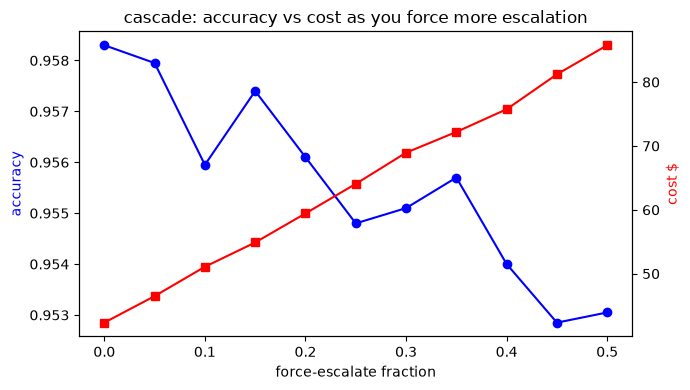

In [13]:
# ---- Solution 5 ----
fracs = np.linspace(0, 0.5, 11)
accs, costs = [], []
for f in fracs:
    a, c, _ = run_cascade("small", "large", force_escalate_frac=f)
    accs.append(a); costs.append(c)
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(fracs, accs, "b-o", label="accuracy"); ax1.set_xlabel("force-escalate fraction")
ax1.set_ylabel("accuracy", color="b")
ax2 = ax1.twinx(); ax2.plot(fracs, costs, "r-s"); ax2.set_ylabel("cost $", color="r")
plt.title("cascade: accuracy vs cost as you force more escalation"); plt.tight_layout(); plt.show()

In [14]:
# ---- Solution 6 ----
def run_cascade_oracle(cheap, expensive):
    cheap_ok = rng.random(N) < MODELS[cheap]["acc"]   # would the cheap model be right?
    esc = ~cheap_ok                                   # escalate exactly when it would be wrong
    ok = cheap_ok.copy()
    ok[esc] = rng.random(esc.sum()) < MODELS[expensive]["acc"]
    cost = cost_per_call(cheap)*N + cost_per_call(expensive)*esc.sum()
    return ok.mean(), cost, esc.mean()

o_a, o_c, o_esc = run_cascade_oracle("small", "large")
n_a, n_c, n_esc = run_cascade("small", "large")
print(f"oracle confidence : acc {o_a:.3f}  cost ${o_c:.2f}  escalated {o_esc:.0%}")
print(f"noisy  confidence : acc {n_a:.3f}  cost ${n_c:.2f}  escalated {n_esc:.0%}")
print("-> better confidence estimation is worth real money; it's why logprob calibration and")
print("   lightweight verifier models are an active area.")

oracle confidence : acc 0.991  cost $25.92  escalated 17%
noisy  confidence : acc 0.959  cost $42.28  escalated 30%
-> better confidence estimation is worth real money; it's why logprob calibration and
   lightweight verifier models are an active area.


### Solution 4 (worked)

`large` input cost per call = `800 · 3.00 / 1e6 = $0.0024`. A 70% cache hit at 90% discount
saves `0.7 · 0.0024 · 0.9 = $0.001512` per call. Break-even vs a $12,000/month engineer:
`12000 / 0.001512 ≈ 7.9M calls/month`. Below that, the cache is still free money — it just
isn't "worth an engineer" until ~8M calls/month.

## Self-check quiz

1. Write the cost-per-call formula.
2. What does it mean for a model to be Pareto-dominated, and what should you do with it?
3. Why do you design latency budgets around p95, not p50?
4. How does streaming change which models meet a latency budget?
5. Explain the cascade router in two sentences. Name one precondition.
6. Your accuracy bar is 0.90 and `mid` hits exactly 0.90 at 1/13 the cost of `frontier`. What
   do you ship, and what do you do with the savings?
7. Prompt caching gives the biggest discount on which part of the prompt, and how do you make
   it effective?

### Answer key

1. `cost = (in_tokens · price_in + out_tokens · price_out)`, prices in $/token (or $/1e6
   tokens with a `/1e6`).
2. Another model is ≥ on every axis (accuracy, cost, latency) and strictly better on at least
   one. Remove it from consideration — it's never the rational pick.
3. Users experience the tail; a good median with a bad p95 means a meaningful fraction of
   requests feel broken. SLAs and user perception track the tail.
4. Streaming shows the first token at TTFT, so a model with a fast first token but slow total
   generation can still feel responsive and pass a "first token < Xs" budget even if its p95
   *total* would fail a non-streaming budget.
5. Run the cheap model first; if its confidence signal says it's likely right, ship that,
   otherwise escalate to a bigger model. Precondition: a usable cheap confidence signal (and a
   task with many easy cases).
6. Ship `mid`. Redirect the ~13× cost savings to volume headroom, a cascade for the hard tail,
   retries, evals, or just margin — don't pay for accuracy you don't need.
7. The input / prefix (stable system prompt, few-shot examples, RAG preamble). Make it
   effective by putting the unchanging content first so the provider can cache a long prefix.

## Where this goes next

- **Day 12 — Model bake-off (hands-on):** build the script that runs the same prompts against
  2–3 real models and produces exactly the cost/latency/accuracy table you just learned to
  read. Then Week 5 starts the retrieval track (embeddings + vector DBs).